In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path where your .npy files are located
PROJECT_DIR = "/content/drive/MyDrive/Dataset/left_hand_acc"

if os.path.exists(PROJECT_DIR):
    print(f"✅ Drive mounted and project directory found at: {PROJECT_DIR}")
    print("Contents:", os.listdir(PROJECT_DIR))
else:
    print(f"❌ Project directory NOT found at: {PROJECT_DIR}. Please check the path in Google Drive.")

Mounted at /content/drive
✅ Drive mounted and project directory found at: /content/drive/MyDrive/Dataset/left_hand_acc
Contents: ['gender.npy', 'Y_activity_left_2s_10_labels.npy', 'X_windows_left_2s_10_full_ds.npy', 'Y_disease_left_2s_10_labels.npy', 'ids.npy', 'data', 'checkpoints', 'confusion_matrices', 'fold_1_Overall_Loss.png', 'fold_1_Activity_Loss.png', 'fold_1_Disease_Loss.png', 'fold_1_Activity_Accuracy.png', 'fold_1_Disease_Accuracy.png', 'fold_2_model.keras', 'fold_2_Overall_Loss.png', 'fold_2_Activity_Loss.png', 'fold_2_Disease_Loss.png', 'fold_2_Activity_Accuracy.png', 'fold_2_Disease_Accuracy.png', 'fold_3_model.keras', 'fold_3_Overall_Loss.png', 'fold_3_Activity_Loss.png', 'fold_3_Disease_Loss.png', 'fold_3_Activity_Accuracy.png', 'fold_3_Disease_Accuracy.png', 'fold_4_model.keras', 'fold_4_Overall_Loss.png', 'fold_4_Activity_Loss.png', 'fold_4_Disease_Loss.png', 'fold_4_Activity_Accuracy.png', 'fold_4_Disease_Accuracy.png', 'fold_5_model.keras', 'fold_5_Overall_Loss.png'

In [ ]:
# ============================================================
# Google Colab setup — mount Google Drive & define all paths
# Run this cell FIRST. Everything (checkpoints, models, plots,
# confusion matrices) is written to your Drive so it survives
# session disconnects and can be resumed.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# --- Project root on Google Drive (change the name if you like) ---
PROJECT_DIR = "/content/drive/MyDrive/Dataset/left_hand_acc"

# --- Where your pre-processed .npy files live ---
# Upload these 5 files into  PROJECT_DIR/data  before running Cell "Load data":
#   X_windows_right_2s_10_full_ds.npy
#   Y_disease_right_2s_10_labels.npy
#   Y_activity_right_2s_10_labels.npy
#   gender.npy
#   ids.npy
DATA_DIR = PROJECT_DIR
# --- Outputs (all persisted to Drive) ---
WORK_DIR       = PROJECT_DIR                                  # saved models & training plots
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")     # per-fold checkpoints (resume-safe)
RESULTS_DIR    = os.path.join(PROJECT_DIR, "confusion_matrices")

for d in (PROJECT_DIR, DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print("Drive mounted. Paths ready:")
print("  DATA_DIR       =", DATA_DIR)
print("  CHECKPOINT_DIR =", CHECKPOINT_DIR)
print("  RESULTS_DIR    =", RESULTS_DIR)
print("  WORK_DIR       =", WORK_DIR)


Mounted at /content/drive
Drive mounted. Paths ready:
  DATA_DIR       = /content/drive/MyDrive/Dataset/left_hand_acc
  CHECKPOINT_DIR = /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints
  RESULTS_DIR    = /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices
  WORK_DIR       = /content/drive/MyDrive/Dataset/left_hand_acc


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [ ]:
import numpy as np
import pandas as pd

# Paths
pre_processed_data = DATA_DIR

# Load numpy files
x = np.load(f"{pre_processed_data}/X_windows_left_2s_10_full_ds.npy")
y_disease = np.load(f"{pre_processed_data}/Y_disease_left_2s_10_labels.npy")
y_activity = np.load(f"{pre_processed_data}/Y_activity_left_2s_10_labels.npy")
y_gender = np.load(f"{pre_processed_data}/gender.npy")
y_id = np.load(f"{pre_processed_data}/ids.npy")

print("Shapes:")
print("X:", x.shape)            # (num_samples, timesteps, features)
print("Disease:", y_disease.shape)
print("Activity:", y_activity.shape)
print("Gender:", y_gender.shape)
print("IDs:", y_id.shape)

Shapes:
X: (288144, 200, 3)
Disease: (288144,)
Activity: (288144,)
Gender: (288144,)
IDs: (288144,)


In [ ]:
# ---- Scaling whole dataset ----

from sklearn.preprocessing import StandardScaler

# Dataset dimensions
N, T, F = x.shape
print(f"Original shape: (N={N}, T={T}, F={F})")

# Flatten to (N*T, F) for scaling
X_2d = x.reshape(-1, F)

# Fit & transform with StandardScaler
scaler = StandardScaler()
X_scaled_2d = scaler.fit_transform(X_2d)

# Reshape back to (N, T, F)
X_scaled = X_scaled_2d.reshape(N, T, F)

print("✅ Scaling complete")
print("Scaled shape:", X_scaled.shape)

# Check mean & std of first feature
print("Feature[0] mean (should be ~0):", X_scaled[..., 0].mean())
print("Feature[0] std (should be ~1):", X_scaled[..., 0].std())

# Preview first sample (first 3 timesteps)
print("\nFirst sample (first 3 timesteps):")
print(X_scaled[0, :3, :])


Original shape: (N=288144, T=200, F=3)
✅ Scaling complete
Scaled shape: (288144, 200, 3)
Feature[0] mean (should be ~0): -8.040752e-09
Feature[0] std (should be ~1): 1.0000001

First sample (first 3 timesteps):
[[ 0.10832798 -0.08097341 -0.02066287]
 [ 0.10799944 -0.07559638 -0.02029927]
 [ 0.09076368 -0.07654238 -0.01326593]]


Sample counts by gender:
   gender   count
0       0  115497
1       1  172647


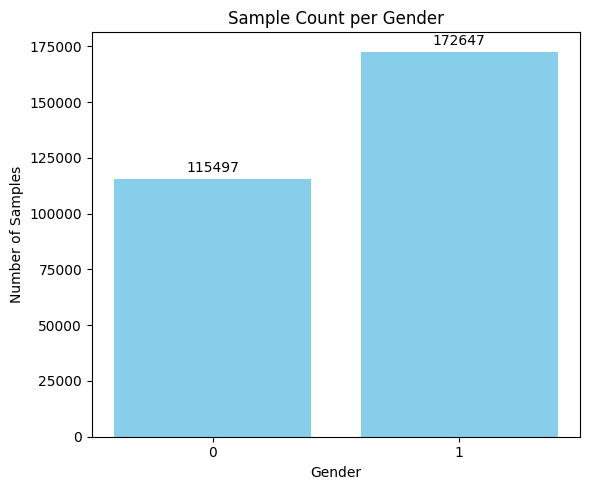

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Count samples per gender ---
unique, counts = np.unique(y_gender, return_counts=True)
gender_df = pd.DataFrame({'gender': unique, 'count': counts})

print("Sample counts by gender:")
print(gender_df)

# --- Bar chart ---
plt.figure(figsize=(6, 5))

# Positions for bars
x_pos = np.arange(len(gender_df))
plt.bar(x_pos, gender_df['count'], color='skyblue')

# Labels and title
plt.xticks(x_pos, gender_df['gender'], rotation=0)
plt.xlabel("Gender")
plt.ylabel("Number of Samples")
plt.title("Sample Count per Gender")

# Annotate values above bars
for i, v in enumerate(gender_df['count']):
    plt.text(i, v + 0.01 * max(gender_df['count']), str(v),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Build dataframe with disease + gender
df = pd.DataFrame({
    "disease": y_disease,
    "activity": y_activity,
    "gender": y_gender
})
df["idx"] = np.arange(len(df))

# Separate classes
df_class1 = df[df["disease"] == 1]
df_class0 = df[df["disease"] == 0]
df_class2 = df[df["disease"] == 2]

# ---- Split Class 1 into 80k vs remaining, stratified by gender ----
df_class1_train, df_class1_finetune = train_test_split(
    df_class1,
    train_size=90000,
    stratify=df_class1["gender"],   # balance genders
    random_state=42
)

# ---- Build chunks ----
df_chunk1 = pd.concat([df_class1_train, df_class0, df_class2])
df_chunk2 = pd.concat([df_class1_finetune, df_class0, df_class2])

# Recover indices
chunk1_idx = df_chunk1["idx"].values
chunk2_idx = df_chunk2["idx"].values

# Subset arrays
X_train = X_scaled[chunk1_idx]
y_disease_train = y_disease[chunk1_idx]
y_activity_train = y_activity[chunk1_idx]

X_finetune = X_scaled[chunk2_idx]
y_disease_finetune = y_disease[chunk2_idx]
y_activity_finetune = y_activity[chunk2_idx]

print("Chunk1 (train) shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Chunk2 (finetune) shapes:", X_finetune.shape, y_disease_finetune.shape, y_activity_finetune.shape)

# Check gender distribution inside Class 1 split
print("\nGender distribution in Class 1 Train:\n", df_class1_train["gender"].value_counts())
print("\nGender distribution in Class 1 Finetune:\n", df_class1_finetune["gender"].value_counts())


Chunk1 (train) shapes: (208579, 200, 3) (208579,) (208579,)
Chunk2 (finetune) shapes: (198144, 200, 3) (198144,) (198144,)

Gender distribution in Class 1 Train:
 gender
1    63590
0    26410
Name: count, dtype: int64

Gender distribution in Class 1 Finetune:
 gender
1    56218
0    23347
Name: count, dtype: int64


In [ ]:
def check_distribution(name, idx, y_disease, y_gender):
    df = pd.DataFrame({
        "disease": y_disease[idx],
        "gender": y_gender[idx]
    })
    print(f"\n{name} distribution:")
    print("Disease counts:\n", df["disease"].value_counts().sort_index())
    print("Gender counts:\n", df["gender"].value_counts())
    print("Disease x Gender:\n", pd.crosstab(df["disease"], df["gender"]))
    print("Unique IDs:", df.shape[0])  # total samples

# Check both chunks
check_distribution("Chunk1 (Train)", chunk1_idx, y_disease, y_gender)
check_distribution("Chunk2 (Finetune)", chunk2_idx, y_disease, y_gender)



Chunk1 (Train) distribution:
Disease counts:
 disease
0    48533
1    90000
2    70046
Name: count, dtype: int64
Gender counts:
 gender
1    116429
0     92150
Name: count, dtype: int64
Disease x Gender:
 gender       0      1
disease              
0        30717  17816
1        26410  63590
2        35023  35023
Unique IDs: 208579

Chunk2 (Finetune) distribution:
Disease counts:
 disease
0    48533
1    79565
2    70046
Name: count, dtype: int64
Gender counts:
 gender
1    109057
0     89087
Name: count, dtype: int64
Disease x Gender:
 gender       0      1
disease              
0        30717  17816
1        23347  56218
2        35023  35023
Unique IDs: 198144


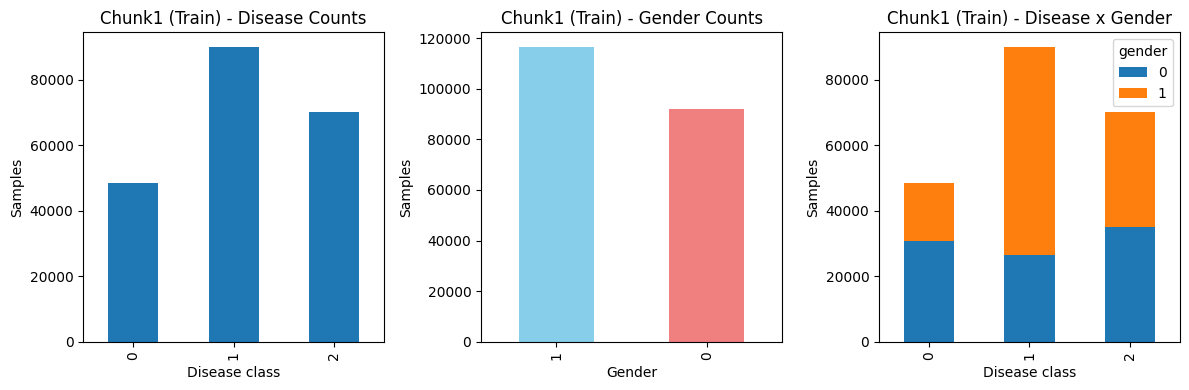

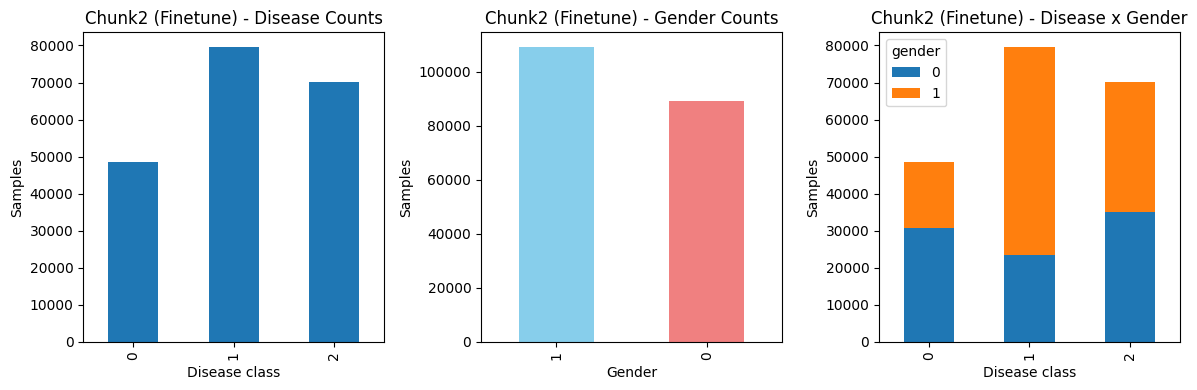

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(name, idx, y_disease, y_gender):
    df = pd.DataFrame({
        "disease": y_disease[idx],
        "gender": y_gender[idx]
    })

    # Disease counts
    disease_counts = df["disease"].value_counts().sort_index()
    gender_counts = df["gender"].value_counts()
    cross_tab = pd.crosstab(df["disease"], df["gender"])

    # --- Plot disease counts ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    disease_counts.plot(kind="bar")
    plt.title(f"{name} - Disease Counts")
    plt.xlabel("Disease class")
    plt.ylabel("Samples")

    # --- Plot gender counts ---
    plt.subplot(1, 3, 2)
    gender_counts.plot(kind="bar", color=["skyblue", "lightcoral"])
    plt.title(f"{name} - Gender Counts")
    plt.xlabel("Gender")
    plt.ylabel("Samples")

    # --- Plot disease × gender cross tab ---
    plt.subplot(1, 3, 3)
    cross_tab.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title(f"{name} - Disease x Gender")
    plt.xlabel("Disease class")
    plt.ylabel("Samples")

    plt.tight_layout()
    plt.show()

# Plot for both chunks
plot_distribution("Chunk1 (Train)", chunk1_idx, y_disease, y_gender)
plot_distribution("Chunk2 (Finetune)", chunk2_idx, y_disease, y_gender)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"🔁 Running {n_splits}-Fold Stratified Cross-Validation...\n")

fold_results = []
fold = 1

for train_idx, val_idx in skf.split(X_train, y_disease_train):
    print(f"===== Fold {fold} =====")
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_disease_train[train_idx], y_disease_train[val_idx]

    y_pred_fold = np.random.choice(np.unique(y_disease_train), size=len(y_val_fold))
    acc = accuracy_score(y_val_fold, y_pred_fold)
    f1 = f1_score(y_val_fold, y_pred_fold, average='weighted')

    print(f"Fold {fold} → Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")
    print("-" * 40)
    fold_results.append({
        'Fold': fold,
        'Accuracy': acc,
        'F1_Score': f1
    })

    fold += 1
results_df = pd.DataFrame(fold_results)

best_fold = results_df.loc[results_df['Accuracy'].idxmax()]
avg_performance = results_df[['Accuracy', 'F1_Score']].mean().to_dict()

print("\n📊 Cross-validation results summary:")
print(results_df)

print("\n🏆 Best Fold Performance:")
print(f"   Fold Number : {int(best_fold['Fold'])}")
print(f"   Accuracy    : {best_fold['Accuracy']:.4f}")
print(f"   F1-Score    : {best_fold['F1_Score']:.4f}")

print("\n📈 Average Performance Across Folds:")
print(f"   Mean Accuracy: {avg_performance['Accuracy']:.4f}")
print(f"   Mean F1-Score: {avg_performance['F1_Score']:.4f}")


🔁 Running 5-Fold Stratified Cross-Validation...

===== Fold 1 =====
Fold 1 → Accuracy: 0.3323 | Weighted F1: 0.3373
----------------------------------------
===== Fold 2 =====
Fold 2 → Accuracy: 0.3329 | Weighted F1: 0.3377
----------------------------------------
===== Fold 3 =====
Fold 3 → Accuracy: 0.3324 | Weighted F1: 0.3376
----------------------------------------
===== Fold 4 =====
Fold 4 → Accuracy: 0.3315 | Weighted F1: 0.3365
----------------------------------------
===== Fold 5 =====
Fold 5 → Accuracy: 0.3324 | Weighted F1: 0.3375
----------------------------------------

📊 Cross-validation results summary:
   Fold  Accuracy  F1_Score
0     1  0.332295  0.337301
1     2  0.332894  0.337724
2     3  0.332366  0.337571
3     4  0.331503  0.336463
4     5  0.332374  0.337500

🏆 Best Fold Performance:
   Fold Number : 2
   Accuracy    : 0.3329
   F1-Score    : 0.3377

📈 Average Performance Across Folds:
   Mean Accuracy: 0.3323
   Mean F1-Score: 0.3373


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Example setup: assuming y_disease_train and StratifiedKFold already defined
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"🔁 Computing class weights for each of {n_splits} folds...\n")

fold = 1
for train_idx, val_idx in skf.split(X_train, y_disease_train):
    print(f"===== Fold {fold} =====")

    # Split training portion for this fold
    y_train_fold = np.asarray(y_disease_train[train_idx])

    # Compute class weights for this fold
    disease_classes = np.unique(y_train_fold)
    disease_weights = compute_class_weight(
        class_weight='balanced',
        classes=disease_classes,
        y=y_train_fold
    )

    # Convert to dictionary
    disease_class_weights = dict(zip(disease_classes, disease_weights))

    print("Disease Class Weights for this fold:")
    for cls, w in disease_class_weights.items():
        print(f"  Class {cls}: {w:.4f}")

    print("-" * 40)
    fold += 1


🔁 Computing class weights for each of 5 folds...

===== Fold 1 =====
Disease Class Weights for this fold:
  Class 0: 1.4326
  Class 1: 0.7725
  Class 2: 0.9926
----------------------------------------
===== Fold 2 =====
Disease Class Weights for this fold:
  Class 0: 1.4326
  Class 1: 0.7725
  Class 2: 0.9926
----------------------------------------
===== Fold 3 =====
Disease Class Weights for this fold:
  Class 0: 1.4326
  Class 1: 0.7725
  Class 2: 0.9926
----------------------------------------
===== Fold 4 =====
Disease Class Weights for this fold:
  Class 0: 1.4325
  Class 1: 0.7725
  Class 2: 0.9926
----------------------------------------
===== Fold 5 =====
Disease Class Weights for this fold:
  Class 0: 1.4325
  Class 1: 0.7725
  Class 2: 0.9926
----------------------------------------


In [ ]:
# Inside your K-Fold loop ⤵️
print(f"===== Fold {fold} =====")

X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
y_train_fold_disease, y_val_fold_disease = y_disease_train[train_idx], y_disease_train[val_idx]
y_train_fold_activity, y_val_fold_activity = y_activity_train[train_idx], y_activity_train[val_idx]

# ✅ Compute class weights for this fold
disease_classes = np.unique(y_train_fold_disease)
disease_weights = compute_class_weight(
    class_weight='balanced',
    classes=disease_classes,
    y=y_train_fold_disease
)
disease_class_weights = dict(zip(disease_classes, disease_weights))

# ✅ Prepare sample weights (for disease & activity outputs)
sample_weights_disease = np.array([disease_class_weights[c] for c in y_train_fold_disease])
sample_weights_activity = np.ones(len(y_train_fold_activity))  # equal weights

# ✅ Display for verification
print("y_disease_train_fold shape:", y_train_fold_disease.shape)
print("sample_weights_disease shape:", sample_weights_disease.shape)

print("y_activity_train_fold shape:", y_train_fold_activity.shape)
print("sample_weights_activity shape:", sample_weights_activity.shape)



===== Fold 6 =====
y_disease_train_fold shape: (166864,)
sample_weights_disease shape: (166864,)
y_activity_train_fold shape: (166864,)
sample_weights_activity shape: (166864,)


In [ ]:
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

In [ ]:
def build_self_attention_block(x, num_heads=4, key_dim=64, dropout_rate=0.15):
    x_norm = layers.LayerNormalization()(x)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_norm, x_norm)
    x = layers.Add()([x, attn_out])  # residual
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
def build_multi_task_model(timesteps=100, features=12,
                           num_disease=3, num_activities=10,
                           lstm_units=64, dense_units=64,
                           dropout_rate=0.15):
    input_layer = layers.Input(shape=(timesteps, features), name="inputs")

    # ---- CNN Block 1 ----
    x = layers.Conv1D(filters=64, kernel_size=7, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(input_layer)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- CNN Block 2 ----
    x = layers.Conv1D(filters=64, kernel_size=5, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- LSTM Layer (Unidirectional) ----
    x = layers.LSTM(lstm_units, return_sequences=True,
                    kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- Self-Attention ----
    x = build_self_attention_block(x, num_heads=4, key_dim=lstm_units, dropout_rate=dropout_rate)

    # ---- Pool sequence to vector ----
    x = layers.GlobalAveragePooling1D()(x)

    # ---- Dense projection ----
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- Outputs ----
    disease_output = layers.Dense(num_disease, activation="softmax", name="disease_output")(x)
    activity_output = layers.Dense(num_activities, activation="softmax", name="activity_output")(x)

    model = Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model


In [ ]:
import tensorflow as tf
import os

def get_callbacks(checkpoint_dir, fold_no=None, save_every=10, best_threshold=None):
    """
    Returns Keras callbacks for model training:
    ✅ Saves model every `save_every` epochs.
    ✅ Saves the best model based on lowest val_loss.
    ✅ Compatible with Kaggle (temporary /working directory).
    """

    # --- Create a subfolder for this fold ---
    fold_dir = os.path.join(checkpoint_dir, f"fold_{fold_no}") if fold_no is not None else checkpoint_dir
    os.makedirs(fold_dir, exist_ok=True)

    # --- Custom callback to save every N epochs ---
    class SaveEveryNEpochs(tf.keras.callbacks.Callback):
        def __init__(self, save_freq, folder):
            super().__init__()
            self.save_freq = save_freq
            self.folder = folder

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            if (epoch + 1) % self.save_freq == 0:
                val_loss = logs.get("val_loss", 0)
                filename = f"epoch_{epoch+1:03d}_valLoss_{val_loss:.4f}.keras"
                filepath = os.path.join(self.folder, filename)
                self.model.save(filepath)
                print(f"\n💾 Checkpoint saved at: {filepath}")

    # --- Callback to always save best model ---
    best_model_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(fold_dir, "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1,
        initial_value_threshold=best_threshold,  # don't overwrite a better historical best on resume
    )

    # ✅ Return both callbacks
    return [
        SaveEveryNEpochs(save_freq=save_every, folder=fold_dir),
        best_model_cb
    ]


In [ ]:
class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_d, y_val_a, fold_no=None):
        super().__init__()
        self.X_val = X_val
        self.y_val_d = y_val_d
        self.y_val_a = y_val_a
        self.fold_no = fold_no

    def on_epoch_end(self, epoch, logs=None):
        y_pred_disease, y_pred_activity = self.model.predict(self.X_val, verbose=0)

        y_pred_disease = np.argmax(y_pred_disease, axis=1)
        y_pred_activity = np.argmax(y_pred_activity, axis=1)

        f1_disease = f1_score(self.y_val_d, y_pred_disease, average="macro")
        f1_activity = f1_score(self.y_val_a, y_pred_activity, average="macro")

        fold_info = f" (Fold {self.fold_no})" if self.fold_no is not None else ""
        print(f"\n🔹 Epoch {epoch+1}{fold_info} - Val Macro F1 | Disease: {f1_disease:.4f} | Activity: {f1_activity:.4f}")

        if logs is not None:
            logs["val_f1_disease"] = f1_disease
            logs["val_f1_activity"] = f1_activity


In [ ]:
def compile_and_train(model,
                      X_train, y_disease_train, y_activity_train,
                      X_val, y_disease_val, y_activity_val,
                      fold_no,
                      base_lr=0.001,
                      batch_size=1024,
                      epochs=100,
                      resume=True,
                      checkpoint_dir=CHECKPOINT_DIR):

    import tensorflow as tf
    import os, re, glob
    from tensorflow.keras.models import load_model

    fold_dir = os.path.join(checkpoint_dir, f"fold_{fold_no}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- Find periodic checkpoints (full model incl. optimizer) to resume from ---
    periodic = glob.glob(os.path.join(fold_dir, "epoch_*_valLoss_*.keras"))
    def _epoch(p):
        m = re.search(r"epoch_(\d+)_", os.path.basename(p))
        return int(m.group(1)) if m else -1
    def _vloss(p):
        m = re.search(r"valLoss_([0-9.]+)\.keras", os.path.basename(p))
        return float(m.group(1)) if m else None

    initial_epoch = 0
    best_threshold = None
    if resume and periodic:
        latest = max(periodic, key=_epoch)
        initial_epoch = _epoch(latest)
        vlosses = [v for v in map(_vloss, periodic) if v is not None]
        best_threshold = min(vlosses) if vlosses else None
        print(f"🔁 Resuming Fold {fold_no} from epoch {initial_epoch} "
              f"({os.path.basename(latest)}); best val_loss so far: {best_threshold}")
        # load_model restores BOTH weights and optimizer state (fixes the optimizer warning)
        model = load_model(latest)
    else:
        print(f"🚀 Starting new training for Fold {fold_no}")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=base_lr),
            loss={
                "disease_output": "sparse_categorical_crossentropy",
                "activity_output": "sparse_categorical_crossentropy",
            },
            metrics={
                "disease_output": ["accuracy"],
                "activity_output": ["accuracy"],
            },
        )

    # --- Nothing left to train (fold already reached target epochs) ---
    if initial_epoch >= epochs:
        print(f"✅ Fold {fold_no} already has {initial_epoch}/{epochs} epochs — no training needed.")
        return model, None

    # --- Callbacks (save every 10 epochs + best model, with resume-safe best tracking) ---
    callbacks = get_callbacks(checkpoint_dir=checkpoint_dir, fold_no=fold_no,
                              save_every=10, best_threshold=best_threshold)

    # --- Train from initial_epoch up to `epochs` (exactly `epochs` total per fold) ---
    history = model.fit(
        X_train,
        {"disease_output": y_disease_train, "activity_output": y_activity_train},
        validation_data=(X_val, {"disease_output": y_disease_val, "activity_output": y_activity_val}),
        epochs=epochs,
        initial_epoch=initial_epoch,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    print(f"✅ Training complete for Fold {fold_no}. Models saved in {fold_dir}")
    return model, history


In [ ]:
# ====================================================
# 🔹 K-Fold Cross Validation with Checkpoint Resuming
# ====================================================
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import os, glob, json

# --- Configuration ---
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_results = []

# --- Global checkpoint directory ---
BASE_CHECKPOINT_DIR = CHECKPOINT_DIR
os.makedirs(BASE_CHECKPOINT_DIR, exist_ok=True)
print(f"✅ Checkpoints will be saved in: {BASE_CHECKPOINT_DIR}")

# ====================================================
# 🔁 K-Fold Loop
# ====================================================
for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_scaled, y_disease), 1):
    print(f"\n==============================")
    print(f"🔹 Fold {fold_no}/{n_splits}")
    print(f"==============================")

    fold_checkpoint_dir = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{fold_no}")
    os.makedirs(fold_checkpoint_dir, exist_ok=True)
    history_path = os.path.join(fold_checkpoint_dir, "history.json")

    # ---- Skip folds already completed in a previous session ----
    if os.path.exists(history_path):
        with open(history_path) as f:
            scores = json.load(f)
        fold_results.append(scores)
        print(f"⏩ Fold {fold_no} already completed — loaded saved metrics, skipping training.")
        print(f"   Disease Acc: {scores['val_disease_acc']:.4f} | Activity Acc: {scores['val_activity_acc']:.4f}")
        continue

    # ---- Split Data ----
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_disease_train_fold, y_disease_val_fold = y_disease[train_idx], y_disease[val_idx]
    y_activity_train_fold, y_activity_val_fold = y_activity[train_idx], y_activity[val_idx]

    # ---- Model Parameters ----
    input_shape = (X_scaled.shape[1], X_scaled.shape[2])
    num_disease = len(np.unique(y_disease))
    num_activities = len(np.unique(y_activity))

    # ---- Build Model (used only if starting fresh; ignored when resuming) ----
    model = build_multi_task_model(
        timesteps=input_shape[0],
        features=input_shape[1],
        num_disease=num_disease,
        num_activities=num_activities,
    )

    # ---- Train Model (resumes from latest checkpoint if present) ----
    model, history = compile_and_train(
        model,
        X_train_fold, y_disease_train_fold, y_activity_train_fold,
        X_val_fold, y_disease_val_fold, y_activity_val_fold,
        fold_no=fold_no,
        base_lr=0.001,
        batch_size=1024,
        epochs=100,
        resume=True,                        # ✅ continue from saved epoch if available
        checkpoint_dir=BASE_CHECKPOINT_DIR
    )

    # ---- Evaluate ----
    scores = model.evaluate(
        X_val_fold,
        {"disease_output": y_disease_val_fold, "activity_output": y_activity_val_fold},
        verbose=0,
        return_dict=True
    )

    # ---- Log Results ----
    fold_record = {
        "fold": fold_no,
        "val_loss": scores.get("loss"),
        "val_disease_acc": scores.get("disease_output_accuracy"),
        "val_activity_acc": scores.get("activity_output_accuracy")
    }
    fold_results.append(fold_record)

    # ---- Mark fold complete (so a future restart skips it) ----
    with open(history_path, "w") as f:
        json.dump(fold_record, f)

    print(f"✅ Fold {fold_no} Results → Disease Acc: {scores.get('disease_output_accuracy'):.4f} | "
          f"Activity Acc: {scores.get('activity_output_accuracy'):.4f}")

# ====================================================
# 📊 Summary of Results
# ====================================================
results_df = pd.DataFrame(fold_results)
print("\n📊 Cross-Validation Summary:")
print(results_df)

best_fold = results_df.loc[results_df["val_disease_acc"].idxmax()]
print(f"\n🏆 Best Fold: {int(best_fold.fold)}")
print(f"   Disease Acc: {best_fold.val_disease_acc:.4f}")
print(f"   Activity Acc: {best_fold.val_activity_acc:.4f}")

print(f"\n📈 Average Disease Acc: {results_df.val_disease_acc.mean():.4f}")
print(f"📈 Average Activity Acc: {results_df.val_activity_acc.mean():.4f}")


✅ Checkpoints will be saved in: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints

🔹 Fold 1/5
⏩ Fold 1 already completed — loaded saved metrics, skipping training.
   Disease Acc: 0.8940 | Activity Acc: 0.9390

🔹 Fold 2/5
⏩ Fold 2 already completed — loaded saved metrics, skipping training.
   Disease Acc: 0.8871 | Activity Acc: 0.9451

🔹 Fold 3/5
⏩ Fold 3 already completed — loaded saved metrics, skipping training.
   Disease Acc: 0.8874 | Activity Acc: 0.9392

🔹 Fold 4/5
⏩ Fold 4 already completed — loaded saved metrics, skipping training.
   Disease Acc: 0.8912 | Activity Acc: 0.9436

🔹 Fold 5/5
⏩ Fold 5 already completed — loaded saved metrics, skipping training.
   Disease Acc: 0.8959 | Activity Acc: 0.9408

📊 Cross-Validation Summary:
   fold  val_loss  val_disease_acc  val_activity_acc
0     1  0.459882         0.893994          0.939041
1     2  0.459323         0.887140          0.945114
2     3  0.469701         0.887418          0.939163
3     4  0.455187         0.89

In [ ]:
results_df = pd.DataFrame(fold_results)
print("\n📊 Cross-Validation Summary:")
print(results_df)

best_fold = results_df.loc[results_df["val_disease_acc"].idxmax()]
print(f"\n🏆 Best Fold: {int(best_fold.fold)}")
print(f"   Disease Acc: {best_fold.val_disease_acc:.4f}")
print(f"   Activity Acc: {best_fold.val_activity_acc:.4f}")

print(f"\n📈 Average Disease Acc: {results_df.val_disease_acc.mean():.4f}")
print(f"📈 Average Activity Acc: {results_df.val_activity_acc.mean():.4f}")



📊 Cross-Validation Summary:
   fold  val_loss  val_disease_acc  val_activity_acc
0     1  0.459882         0.893994          0.939041
1     2  0.459323         0.887140          0.945114
2     3  0.469701         0.887418          0.939163
3     4  0.455187         0.891218          0.943605
4     5  0.449614         0.895919          0.940793

🏆 Best Fold: 5
   Disease Acc: 0.8959
   Activity Acc: 0.9408

📈 Average Disease Acc: 0.8911
📈 Average Activity Acc: 0.9415


In [ ]:
X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
y_disease_train_fold, y_disease_val_fold = y_disease[train_idx], y_disease[val_idx]
y_activity_train_fold, y_activity_val_fold = y_activity[train_idx], y_activity[val_idx]

In [ ]:
import os
import tensorflow as tf

# --- Save directory inside Kaggle working ---
save_dir = WORK_DIR
os.makedirs(save_dir, exist_ok=True)

# Model path for the final saved model
model_path = os.path.join(save_dir, "best_fold_model.keras")

# --- Load the best model from the cross-validation folds ---
# The `best_fold` variable (from kernel state) contains info about the best performing fold.
# The actual model is saved by ModelCheckpoint during training in the fold's checkpoint directory.
# BASE_CHECKPOINT_DIR and best_fold are available from previous cells' execution.

# Ensure 'best_fold' variable is available (from C6k4Ga6avGLE)
if 'best_fold' not in locals() and 'best_fold' not in globals():
    raise NameError("best_fold variable not found. Please run cell 'C6k4Ga6avGLE' first.")

best_fold_no = int(best_fold['fold'])
best_fold_checkpoint_dir = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{best_fold_no}")

# Load the 'best_model.keras' saved by ModelCheckpoint for the best fold
loaded_best_model_path = os.path.join(best_fold_checkpoint_dir, "best_model.keras")

if not os.path.exists(loaded_best_model_path):
    raise FileNotFoundError(f"Best model for fold {best_fold_no} not found at {loaded_best_model_path}")

model = tf.keras.models.load_model(loaded_best_model_path)
print(f"✅ Successfully loaded best model from Fold {best_fold_no} at: {loaded_best_model_path}")

# Save this loaded model to the specified model_path
model.save(model_path)

print(f"✅ Model saved at: {model_path}")

✅ Successfully loaded best model from Fold 5 at: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_5/best_model.keras
✅ Model saved at: /content/drive/MyDrive/Dataset/left_hand_acc/best_fold_model.keras


In [ ]:
import matplotlib.pyplot as plt
import os

# --- Save directory ---
save_dir = WORK_DIR
os.makedirs(save_dir, exist_ok=True)

# Utility function to plot and save training curves for each fold
def plot_history(history, fold_no, save_dir=None):
    metrics = history.history

    # List of plots to generate
    plots = [
        ("Overall Loss", "loss", "val_loss", "Loss"),
        ("Activity Loss", "activity_output_loss", "val_activity_output_loss", "Loss"),
        ("Disease Loss", "disease_output_loss", "val_disease_output_loss", "Loss"),
        ("Activity Accuracy", "activity_output_accuracy", "val_activity_output_accuracy", "Accuracy"),
        ("Disease Accuracy", "disease_output_accuracy", "val_disease_output_accuracy", "Accuracy"),
    ]

    for title, train_metric, val_metric, ylabel in plots:
        plt.figure()
        plt.plot(metrics[train_metric], label=f"Train {title}")
        plt.plot(metrics[val_metric], label=f"Val {title}")
        plt.title(f"Fold {fold_no} - {title}")
        plt.xlabel("Epochs")
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True)

        # Save plot if save_dir is provided
        if save_dir:
            plot_path = os.path.join(save_dir, f"fold_{fold_no}_{title.replace(' ', '_')}.png")
            plt.savefig(plot_path)
            print(f"📊 Fold {fold_no} plot saved: {plot_path}")

        plt.show()
        plt.close()

# ===============================
# Inside K-Fold Loop, after training each fold
# ===============================
# Resetting fold_results to avoid duplicates if re-running
fold_results = []

for fold_no, (train_idx, val_idx) in enumerate(kf.split(X_scaled, y_disease), 1):
    fold_checkpoint_dir = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{fold_no}")
    history_path = os.path.join(fold_checkpoint_dir, "history.json")

    # Check if fold was already completed
    if os.path.exists(history_path):
        print(f"⏩ Fold {fold_no} already completed - skipping plotting.")
        continue

    # ... (Assuming training happens here in your main loop) ...
    # Only call these if 'history' and 'model' were defined by training in this session
    if 'history' in locals() and 'model' in locals():
        # Save model for this fold
        fold_model_path = os.path.join(save_dir, f"fold_{fold_no}_model.keras")
        model.save(fold_model_path)
        print(f"✅ Fold {fold_no} model saved at: {fold_model_path}")

        # Plot and save training curves for this fold
        plot_history(history, fold_no=fold_no, save_dir=save_dir)

⏩ Fold 1 already completed - skipping plotting.
⏩ Fold 2 already completed - skipping plotting.
⏩ Fold 3 already completed - skipping plotting.
⏩ Fold 4 already completed - skipping plotting.
⏩ Fold 5 already completed - skipping plotting.



🔹 Evaluating Fold 1/5
✅ Loaded model: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_1/epoch_100_valLoss_0.4599.keras

📄 Disease Classification Report (Fold 1):
              precision    recall  f1-score   support

     Healthy     0.8628    0.8420    0.8522      9605
 Parkinson's     0.9083    0.9356    0.9217     33978
          DD     0.8784    0.8289    0.8529     14046

    accuracy                         0.8940     57629
   macro avg     0.8831    0.8688    0.8756     57629
weighted avg     0.8934    0.8940    0.8934     57629



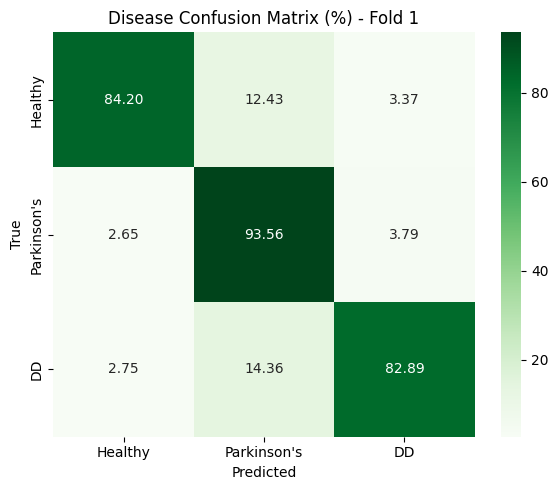


📄 Activity Classification Report (Fold 1):
              precision    recall  f1-score   support

   CrossArms     0.9098    0.8889    0.8992      4859
   DrinkGlas     0.9226    0.9004    0.9114      4780
 Entrainment     0.9611    0.9891    0.9749      9550
  HoldWeight     0.9639    0.9544    0.9591      4805
    LiftHold     0.8811    0.8923    0.8867      4744
 PointFinger     0.9405    0.9763    0.9581      4761
     Relaxed     0.9873    0.9816    0.9845      9694
 StretchHold     0.8968    0.8986    0.8977      4863
  TouchIndex     0.9411    0.8673    0.9027      4739
   TouchNose     0.9155    0.9483    0.9316      4834

    accuracy                         0.9390     57629
   macro avg     0.9320    0.9297    0.9306     57629
weighted avg     0.9391    0.9390    0.9388     57629



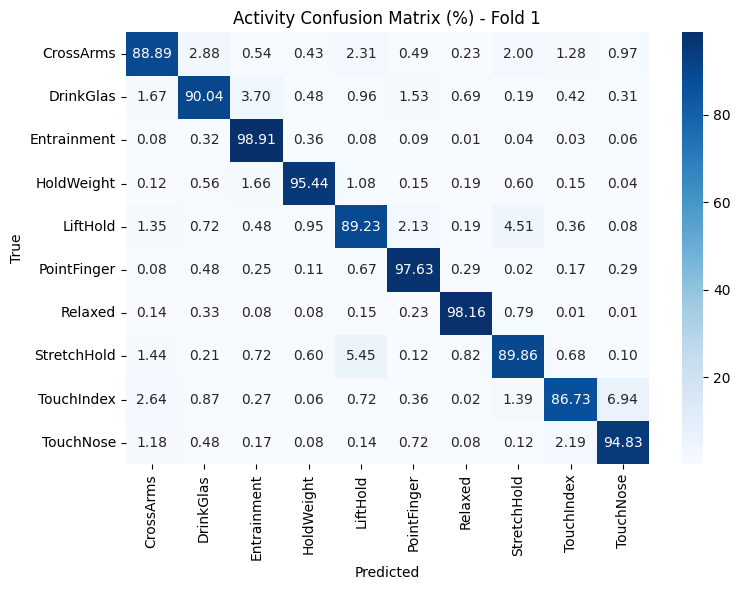

✅ Confusion matrices saved for Fold 1 in: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices/fold_1

🔹 Evaluating Fold 2/5
✅ Loaded model: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_2/epoch_100_valLoss_0.4593.keras

📄 Disease Classification Report (Fold 2):
              precision    recall  f1-score   support

     Healthy     0.8124    0.8743    0.8422      9738
 Parkinson's     0.9230    0.9134    0.9181     33895
          DD     0.8563    0.8326    0.8443     13996

    accuracy                         0.8871     57629
   macro avg     0.8639    0.8734    0.8682     57629
weighted avg     0.8881    0.8871    0.8874     57629



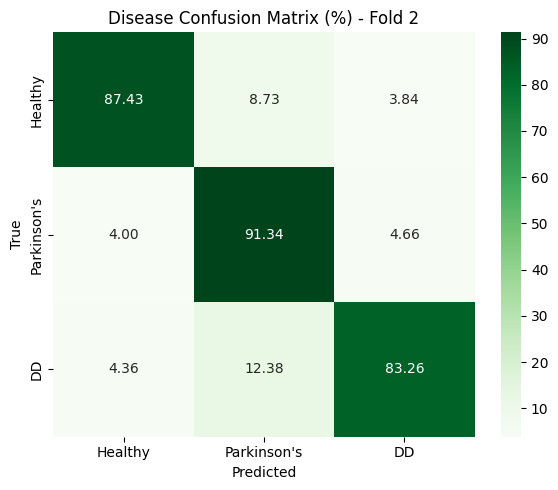


📄 Activity Classification Report (Fold 2):
              precision    recall  f1-score   support

   CrossArms     0.9214    0.8764    0.8983      4759
   DrinkGlas     0.9425    0.9050    0.9234      4893
 Entrainment     0.9725    0.9869    0.9796      9735
  HoldWeight     0.9703    0.9608    0.9655      4766
    LiftHold     0.8918    0.8956    0.8937      4695
 PointFinger     0.9539    0.9822    0.9678      4822
     Relaxed     0.9838    0.9862    0.9850      9593
 StretchHold     0.8941    0.9275    0.9105      4827
  TouchIndex     0.9349    0.8863    0.9100      4733
   TouchNose     0.9186    0.9586    0.9382      4806

    accuracy                         0.9451     57629
   macro avg     0.9384    0.9365    0.9372     57629
weighted avg     0.9452    0.9451    0.9449     57629



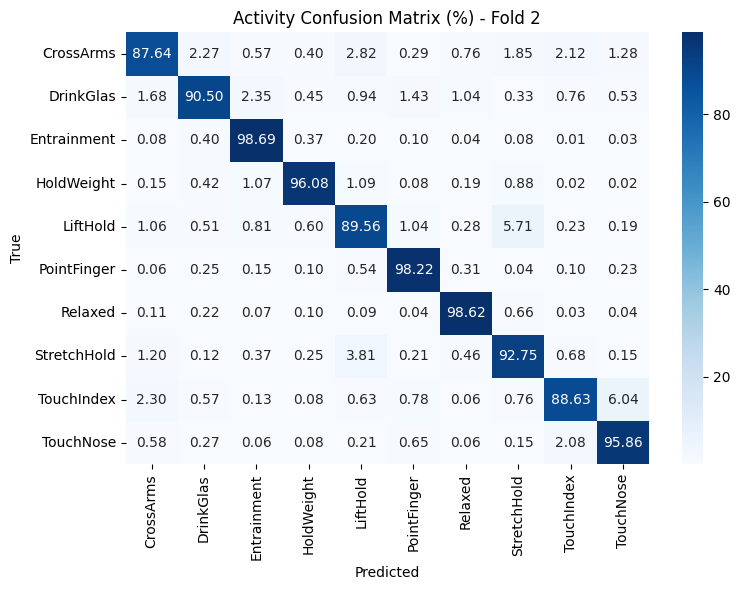

✅ Confusion matrices saved for Fold 2 in: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices/fold_2

🔹 Evaluating Fold 3/5
✅ Loaded model: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_3/epoch_100_valLoss_0.4697.keras

📄 Disease Classification Report (Fold 3):
              precision    recall  f1-score   support

     Healthy     0.8113    0.8624    0.8361      9645
 Parkinson's     0.9224    0.9151    0.9187     33920
          DD     0.8586    0.8378    0.8481     14064

    accuracy                         0.8874     57629
   macro avg     0.8641    0.8718    0.8676     57629
weighted avg     0.8882    0.8874    0.8876     57629



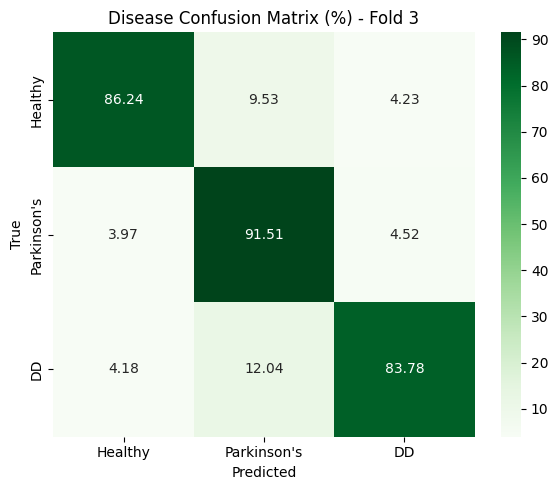


📄 Activity Classification Report (Fold 3):
              precision    recall  f1-score   support

   CrossArms     0.8955    0.8964    0.8960      4780
   DrinkGlas     0.9412    0.8960    0.9180      4819
 Entrainment     0.9752    0.9799    0.9776      9368
  HoldWeight     0.9575    0.9527    0.9551      4780
    LiftHold     0.8753    0.8657    0.8705      4953
 PointFinger     0.9544    0.9746    0.9644      4811
     Relaxed     0.9799    0.9884    0.9841      9695
 StretchHold     0.8771    0.9162    0.8962      4808
  TouchIndex     0.9317    0.8893    0.9100      4894
   TouchNose     0.9307    0.9466    0.9386      4721

    accuracy                         0.9392     57629
   macro avg     0.9318    0.9306    0.9311     57629
weighted avg     0.9392    0.9392    0.9390     57629



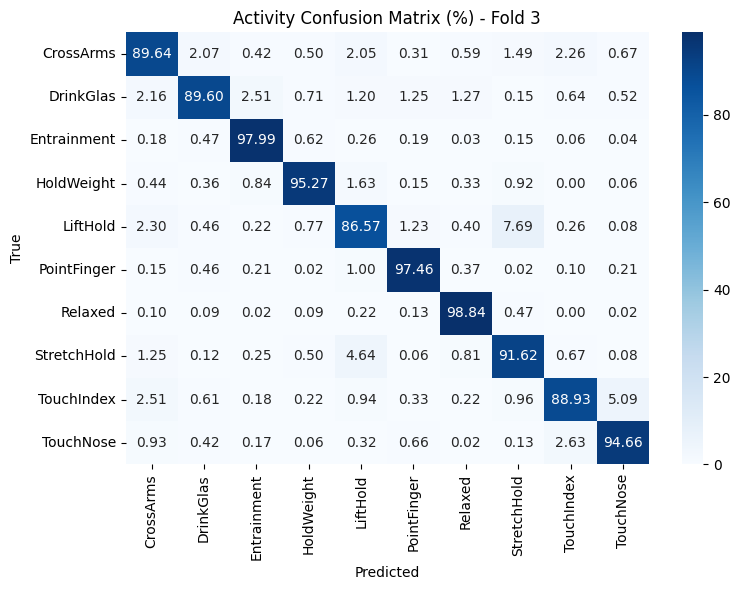

✅ Confusion matrices saved for Fold 3 in: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices/fold_3

🔹 Evaluating Fold 4/5
✅ Loaded model: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_4/epoch_100_valLoss_0.4552.keras

📄 Disease Classification Report (Fold 4):
              precision    recall  f1-score   support

     Healthy     0.8576    0.8356    0.8464      9779
 Parkinson's     0.9115    0.9329    0.9221     33893
          DD     0.8626    0.8290    0.8455     13957

    accuracy                         0.8912     57629
   macro avg     0.8772    0.8658    0.8713     57629
weighted avg     0.8905    0.8912    0.8907     57629



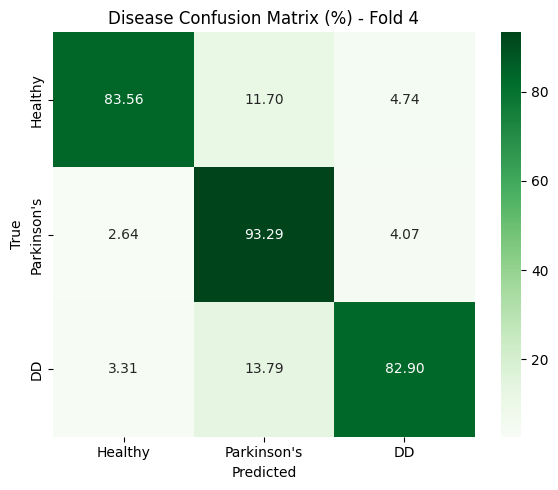


📄 Activity Classification Report (Fold 4):
              precision    recall  f1-score   support

   CrossArms     0.8887    0.8936    0.8911      4764
   DrinkGlas     0.9447    0.8912    0.9172      4696
 Entrainment     0.9813    0.9793    0.9803      9706
  HoldWeight     0.9678    0.9636    0.9657      4832
    LiftHold     0.8950    0.8831    0.8890      4799
 PointFinger     0.9684    0.9612    0.9648      4849
     Relaxed     0.9815    0.9883    0.9849      9438
 StretchHold     0.8773    0.9376    0.9064      4856
  TouchIndex     0.9202    0.9108    0.9155      4833
   TouchNose     0.9402    0.9460    0.9431      4856

    accuracy                         0.9436     57629
   macro avg     0.9365    0.9355    0.9358     57629
weighted avg     0.9439    0.9436    0.9436     57629



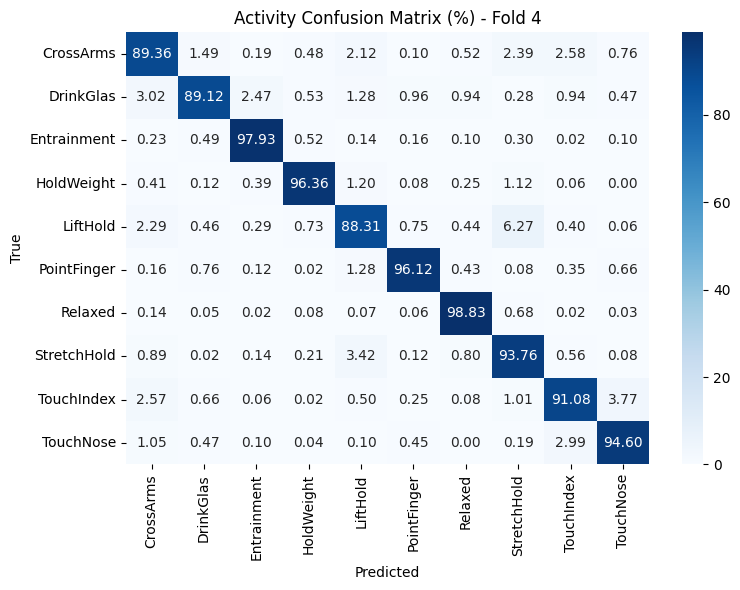

✅ Confusion matrices saved for Fold 4 in: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices/fold_4

🔹 Evaluating Fold 5/5
✅ Loaded model: /content/drive/MyDrive/Dataset/left_hand_acc/checkpoints/fold_5/epoch_100_valLoss_0.4496.keras

📄 Disease Classification Report (Fold 5):
              precision    recall  f1-score   support

     Healthy     0.8901    0.8128    0.8497      9766
 Parkinson's     0.9128    0.9412    0.9268     33879
          DD     0.8568    0.8442    0.8505     13983

    accuracy                         0.8959     57628
   macro avg     0.8866    0.8661    0.8757     57628
weighted avg     0.8954    0.8959    0.8952     57628



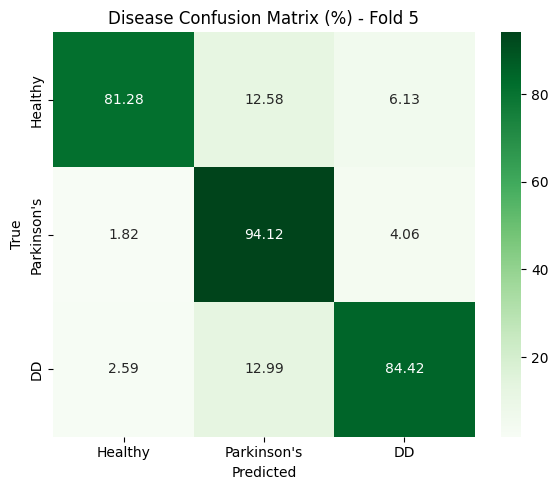


📄 Activity Classification Report (Fold 5):
              precision    recall  f1-score   support

   CrossArms     0.9012    0.8841    0.8926      4851
   DrinkGlas     0.9484    0.9026    0.9249      4825
 Entrainment     0.9756    0.9785    0.9770      9666
  HoldWeight     0.9663    0.9501    0.9581      4830
    LiftHold     0.8939    0.8687    0.8812      4822
 PointFinger     0.9509    0.9744    0.9625      4770
     Relaxed     0.9795    0.9905    0.9850      9605
 StretchHold     0.8817    0.9313    0.9058      4659
  TouchIndex     0.9275    0.8901    0.9084      4814
   TouchNose     0.9091    0.9507    0.9294      4786

    accuracy                         0.9408     57628
   macro avg     0.9334    0.9321    0.9325     57628
weighted avg     0.9409    0.9408    0.9406     57628



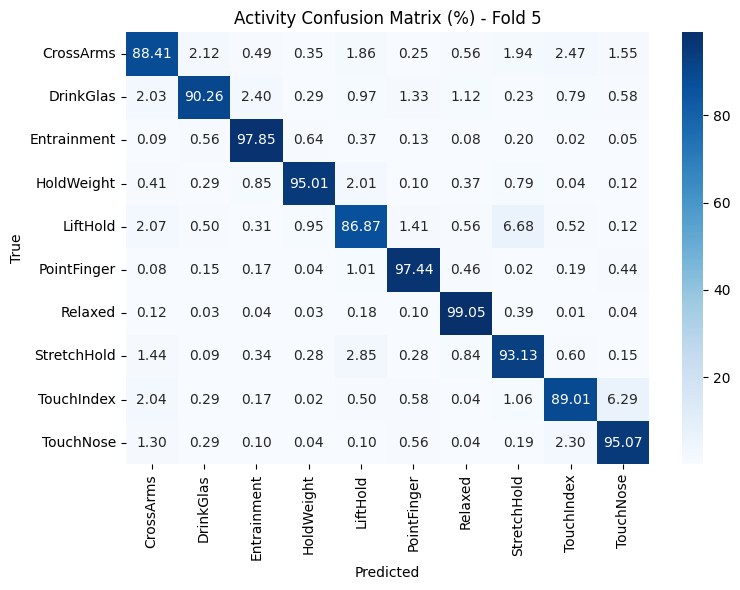

✅ Confusion matrices saved for Fold 5 in: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrices/fold_5

🎯 All folds evaluated successfully!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from sklearn.model_selection import KFold

# --- Class name mappings (integer label -> display name) ---
DISEASE_NAMES = ["Healthy", "Parkinson's", "DD"]
ACTIVITY_NAMES = ["CrossArms", "DrinkGlas", "Entrainment", "HoldWeight",
                  "LiftHold", "PointFinger", "Relaxed", "StretchHold",
                  "TouchIndex", "TouchNose"]
# ====================================================
# Configuration
# ====================================================
BASE_CHECKPOINT_DIR = CHECKPOINT_DIR
RESULTS_DIR = os.path.join(PROJECT_DIR, "confusion_matrices")
os.makedirs(RESULTS_DIR, exist_ok=True)

n_splits = 5  # same as used in training
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Your full dataset (used during training)
# Must already be loaded before running this script
# Example:
# X_scaled = np.load("/kaggle/input/yourdata/X_scaled.npy")
# y_disease = np.load("/kaggle/input/yourdata/y_disease.npy")
# y_activity = np.load("/kaggle/input/yourdata/y_activity.npy")

# ====================================================
# Loop through folds
# ====================================================
fold_no = 1
for train_idx, val_idx in kf.split(X_scaled, y_disease):
    print(f"\n==============================")
    print(f"🔹 Evaluating Fold {fold_no}/{n_splits}")
    print(f"==============================")

    # --- Load validation data ---
    X_val_fold = X_scaled[val_idx]
    y_disease_val_fold = y_disease[val_idx]
    y_activity_val_fold = y_activity[val_idx]

    # --- Locate saved model checkpoint ---
    fold_checkpoint_dir = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{fold_no}")
    model_files = [f for f in os.listdir(fold_checkpoint_dir) if f.endswith(".keras") or f.endswith(".h5")]

    if not model_files:
        print(f"⚠️ No saved model found in {fold_checkpoint_dir}. Skipping fold {fold_no}.")
        fold_no += 1
        continue

    # Load the latest (or best) checkpoint file
    model_path = os.path.join(fold_checkpoint_dir, sorted(model_files)[-1])
    print(f"✅ Loaded model: {model_path}")

    model = load_model(model_path)

    # --- Predictions ---
    y_pred_val = model.predict(X_val_fold, batch_size=1024, verbose=0)
    y_pred_disease = np.argmax(y_pred_val[0], axis=1)
    y_pred_activity = np.argmax(y_pred_val[1], axis=1)

    # Convert y_true from one-hot if needed
    if y_disease_val_fold.ndim > 1:
        y_disease_val_fold = np.argmax(y_disease_val_fold, axis=1)
    if y_activity_val_fold.ndim > 1:
        y_activity_val_fold = np.argmax(y_activity_val_fold, axis=1)

    # Create fold results folder
    fold_result_dir = os.path.join(RESULTS_DIR, f"fold_{fold_no}")
    os.makedirs(fold_result_dir, exist_ok=True)

    # ====================================================
    # 🧠 Disease Confusion Matrix
    # ====================================================
    disease_classes = np.unique(np.concatenate([y_disease_val_fold, y_pred_disease]))
    print(f"\n📄 Disease Classification Report (Fold {fold_no}):")
    print(classification_report(
        y_disease_val_fold,
        y_pred_disease,
        labels=disease_classes,
        target_names=[DISEASE_NAMES[i] for i in disease_classes],
        digits=4
    ))

    cm_disease = confusion_matrix(y_disease_val_fold, y_pred_disease, labels=disease_classes)
    cm_disease_pct = cm_disease.astype(float) / cm_disease.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_disease_pct, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=[DISEASE_NAMES[i] for i in disease_classes],
                yticklabels=[DISEASE_NAMES[i] for i in disease_classes])
    plt.title(f"Disease Confusion Matrix (%) - Fold {fold_no}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_result_dir, f"confusion_matrix_disease_fold_{fold_no}.png"))
    plt.show()

    # ====================================================
    # 🏃 Activity Confusion Matrix
    # ====================================================
    activity_classes = np.unique(np.concatenate([y_activity_val_fold, y_pred_activity]))
    print(f"\n📄 Activity Classification Report (Fold {fold_no}):")
    print(classification_report(
        y_activity_val_fold,
        y_pred_activity,
        labels=activity_classes,
        target_names=[ACTIVITY_NAMES[i] for i in activity_classes],
        digits=4
    ))

    cm_activity = confusion_matrix(y_activity_val_fold, y_pred_activity, labels=activity_classes)
    cm_activity_pct = cm_activity.astype(float) / cm_activity.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_activity_pct, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=[ACTIVITY_NAMES[i] for i in activity_classes],
                yticklabels=[ACTIVITY_NAMES[i] for i in activity_classes])
    plt.title(f"Activity Confusion Matrix (%) - Fold {fold_no}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_result_dir, f"confusion_matrix_activity_fold_{fold_no}.png"))
    plt.show()

    print(f"✅ Confusion matrices saved for Fold {fold_no} in: {fold_result_dir}")

    fold_no += 1

print("\n🎯 All folds evaluated successfully!")


In [ ]:
from sklearn.model_selection import train_test_split

X_train_f, X_temp_f, y_disease_train_f, y_disease_temp_f, y_activity_train_f, y_activity_temp_f = train_test_split(
    X_finetune,
    y_disease_finetune,
    y_activity_finetune,
    test_size=0.3,
    random_state=42,
    stratify=y_disease_finetune
)

X_val_f, X_test_f, y_disease_val_f, y_disease_test_f, y_activity_val_f, y_activity_test_f = train_test_split(
    X_temp_f,
    y_disease_temp_f,
    y_activity_temp_f,
    test_size=0.5,
    random_state=42,
    stratify=y_disease_temp_f
)


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
from tensorflow import keras

class MetricsCallback(keras.callbacks.Callback):
    """
    Custom Keras callback to compute F1-score and Accuracy for
    multi-task outputs (disease + activity) at the end of each epoch.
    """
    def __init__(self, val_data):
        super().__init__()
        self.validation_data = val_data  # Tuple: (X_val, y_val_dict)

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_disease_val = y_val_dict["disease_output"]
        y_activity_val = y_val_dict["activity_output"]

        # Make predictions
        y_pred = self.model.predict(X_val, verbose=0)
        y_pred_disease = np.argmax(y_pred[0], axis=1)
        y_pred_activity = np.argmax(y_pred[1], axis=1)

        # Compute metrics
        f1_disease = f1_score(y_disease_val, y_pred_disease, average="macro")
        acc_disease = accuracy_score(y_disease_val, y_pred_disease)

        f1_activity = f1_score(y_activity_val, y_pred_activity, average="macro")
        acc_activity = accuracy_score(y_activity_val, y_pred_activity)

        # Print metrics
        print(
            f"\n📊 Epoch {epoch+1} Metrics → "
            f"Disease: F1 = {f1_disease:.4f}, Acc = {acc_disease:.4f} | "
            f"Activity: F1 = {f1_activity:.4f}, Acc = {acc_activity:.4f}"
        )


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau

# --- Recompile pretrained model with fixed learning rate ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "disease_output": "sparse_categorical_crossentropy",
        "activity_output": "sparse_categorical_crossentropy"
    },
    metrics={
        "disease_output": ["accuracy"],
        "activity_output": ["accuracy"]
    }
)

# --- Learning rate scheduler ---
reduce_lr = ReduceLROnPlateau(
    monitor="val_disease_output_accuracy",  # monitor disease validation accuracy
    factor=0.5,
    patience=4,
    mode="max",
    verbose=1
)

# --- Custom Metrics Callback ---
metrics_cb = MetricsCallback(
    val_data=(
        X_val_f,
        {
            "disease_output": y_disease_val_f,
            "activity_output": y_activity_val_f
        }
    )
)

# --- Fine-tuning phase ---
history_finetune = model.fit(
    X_train_f,
    {
        "disease_output": y_disease_train_f,
        "activity_output": y_activity_train_f
    },
    validation_data=(
        X_val_f,
        {
            "disease_output": y_disease_val_f,
            "activity_output": y_activity_val_f
        }
    ),
    epochs=50,
    batch_size=512,
    callbacks=[reduce_lr, metrics_cb],
    verbose=1
)


Epoch 1/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - activity_output_accuracy: 0.9338 - activity_output_loss: 0.1919 - disease_output_accuracy: 0.8567 - disease_output_loss: 0.3513 - loss: 0.5523
📊 Epoch 1 Metrics → Disease: F1 = 0.9263, Acc = 0.9269 | Activity: F1 = 0.9602, Acc = 0.9650
271/271 ━━━━━━━━━━━━━━━━━━━━ 66s 207ms/step - activity_output_accuracy: 0.9347 - activity_output_loss: 0.1882 - disease_output_accuracy: 0.8611 - disease_output_loss: 0.3418 - loss: 0.5390 - val_activity_output_accuracy: 0.9650 - val_activity_output_loss: 0.1017 - val_disease_output_accuracy: 0.9269 - val_disease_output_loss: 0.1961 - val_loss: 0.3070 - learning_rate: 1.0000e-04
Epoch 2/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - activity_output_accuracy: 0.9374 - activity_output_loss: 0.1783 - disease_output_accuracy: 0.8679 - disease_output_loss: 0.3277 - loss: 0.5150
📊 Epoch 2 Metrics → Disease: F1 = 0.9264, Acc = 0.9268 | Activity: F1 = 0.9610, Acc = 0.9657
271/271 ━━━━━━━━━━━━━━━━━━━━ 81s 2

In [ ]:
# --- Save Fine-tuned Model ---
save_path = os.path.join(WORK_DIR, "fine_tuned_model_kf_left_2s_lstm.keras")
model.save(save_path)
print(f"✅ Fine-tuned model saved at: {save_path}")


✅ Fine-tuned model saved at: /content/drive/MyDrive/Dataset/left_hand_acc/fine_tuned_model_kf_left_2s_lstm.keras


📊 Plot saved at: /content/drive/MyDrive/Dataset/left_hand_acc/fine_tune_accuracy.png


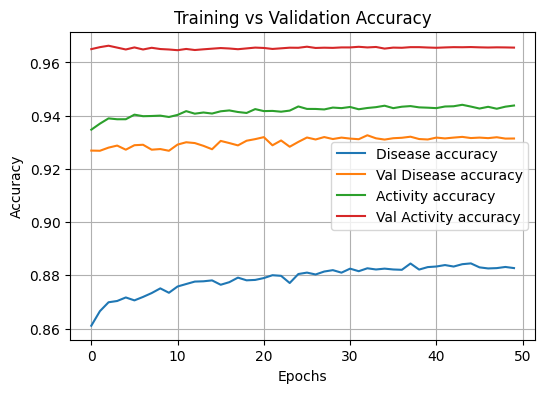

📊 Plot saved at: /content/drive/MyDrive/Dataset/left_hand_acc/fine_tune_loss.png


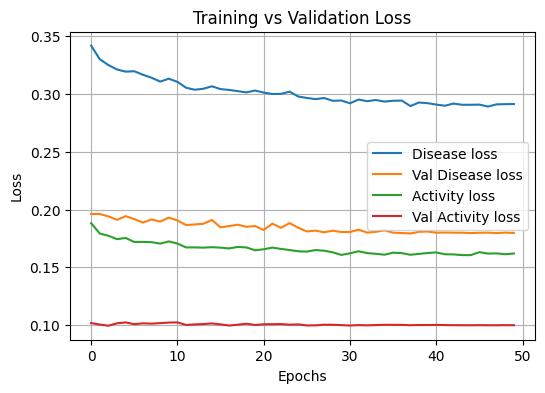

In [ ]:
import matplotlib.pyplot as plt
import os

# --- Optional: save directory ---
save_dir = WORK_DIR
os.makedirs(save_dir, exist_ok=True)

# ✅ Function to plot curves
def plot_curves(history, metric, title, save_path=None):
    plt.figure(figsize=(6,4))
    plt.plot(history.history[f"disease_output_{metric}"], label=f"Disease {metric}")
    plt.plot(history.history[f"val_disease_output_{metric}"], label=f"Val Disease {metric}")
    plt.plot(history.history[f"activity_output_{metric}"], label=f"Activity {metric}")
    plt.plot(history.history[f"val_activity_output_{metric}"], label=f"Val Activity {metric}")
    plt.xlabel("Epochs")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.grid(True)

    # Save plot if path provided
    if save_path:
        plt.savefig(save_path)
        print(f"📊 Plot saved at: {save_path}")

    plt.show()
    plt.close()

# ✅ Plot Accuracy curves
plot_curves(
    history_finetune,
    metric="accuracy",
    title="Training vs Validation Accuracy",
    save_path=os.path.join(save_dir, "fine_tune_accuracy.png")
)

# ✅ Plot Loss curves
plot_curves(
    history_finetune,
    metric="loss",
    title="Training vs Validation Loss",
    save_path=os.path.join(save_dir, "fine_tune_loss.png")
)



🧠 Disease Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9111    0.9477    0.9290      7280
 Parkinson's     0.9414    0.9233    0.9323     11935
          DD     0.9335    0.9279    0.9306     10507

    accuracy                         0.9309     29722
   macro avg     0.9287    0.9330    0.9307     29722
weighted avg     0.9312    0.9309    0.9309     29722



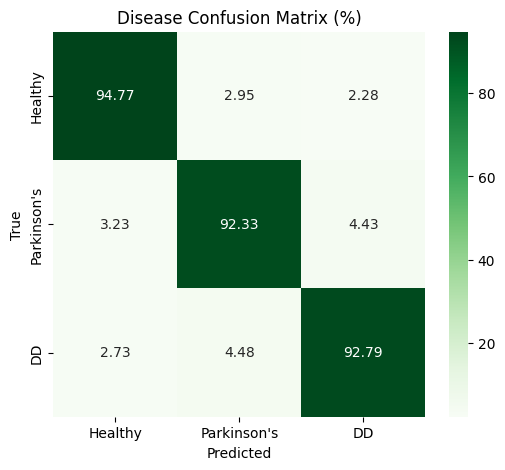

📊 Disease confusion matrix saved at: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrix_disease_finetune.png

🏃 Activity Classification Report:
              precision    recall  f1-score   support

   CrossArms     0.9472    0.9340    0.9406      2517
   DrinkGlas     0.9689    0.9435    0.9560      2443
 Entrainment     0.9817    0.9918    0.9867      4877
  HoldWeight     0.9712    0.9766    0.9739      2519
    LiftHold     0.9425    0.9213    0.9318      2527
 PointFinger     0.9778    0.9826    0.9802      2418
     Relaxed     0.9914    0.9926    0.9920      4990
 StretchHold     0.9302    0.9625    0.9461      2424
  TouchIndex     0.9509    0.9268    0.9387      2485
   TouchNose     0.9487    0.9687    0.9586      2522

    accuracy                         0.9652     29722
   macro avg     0.9611    0.9600    0.9605     29722
weighted avg     0.9652    0.9652    0.9652     29722



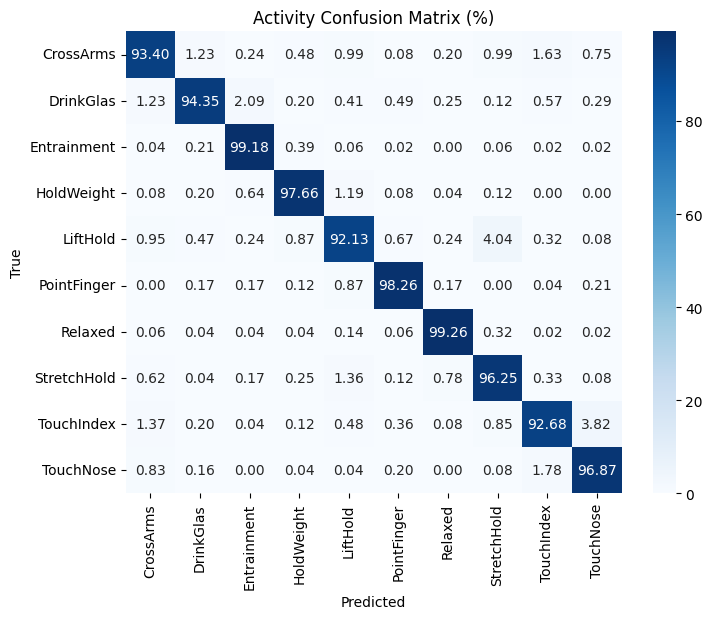

📊 Activity confusion matrix saved at: /content/drive/MyDrive/Dataset/left_hand_acc/confusion_matrix_activity_finetune.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Class name mappings (integer label -> display name) ---
DISEASE_NAMES = ["Healthy", "Parkinson's", "DD"]
ACTIVITY_NAMES = ["CrossArms", "DrinkGlas", "Entrainment", "HoldWeight",
                  "LiftHold", "PointFinger", "Relaxed", "StretchHold",
                  "TouchIndex", "TouchNose"]
# --- Save directory ---
save_dir = WORK_DIR
os.makedirs(save_dir, exist_ok=True)

# ---- Predictions on fine-tuned test set ----
y_pred_test = model.predict(X_test_f, batch_size=1024, verbose=0)

# Convert softmax outputs → integer class predictions
y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# Ensure y_test are integers (not one-hot)
if y_disease_test_f.ndim > 1:
    y_disease_test_f = np.argmax(y_disease_test_f, axis=1)

if y_activity_test_f.ndim > 1:
    y_activity_test_f = np.argmax(y_activity_test_f, axis=1)

# ===========================
# Disease Confusion Matrix
# ===========================
disease_classes = np.unique(np.concatenate([y_disease_test_f, y_pred_disease]))

print("\n🧠 Disease Classification Report:")
print(classification_report(
    y_disease_test_f,
    y_pred_disease,
    labels=disease_classes,
    target_names=[DISEASE_NAMES[i] for i in disease_classes],
    digits=4
))

cm_disease = confusion_matrix(y_disease_test_f, y_pred_disease, labels=disease_classes)
cm_disease_pct = cm_disease.astype("float") / cm_disease.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))
sns.heatmap(cm_disease_pct, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=[DISEASE_NAMES[i] for i in disease_classes],
            yticklabels=[DISEASE_NAMES[i] for i in disease_classes])
plt.title("Disease Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
disease_cm_path = os.path.join(save_dir, "confusion_matrix_disease_finetune.png")
plt.savefig(disease_cm_path)
plt.show()
print(f"📊 Disease confusion matrix saved at: {disease_cm_path}")

# ===========================
# Activity Confusion Matrix
# ===========================
activity_classes = np.unique(np.concatenate([y_activity_test_f, y_pred_activity]))

print("\n🏃 Activity Classification Report:")
print(classification_report(
    y_activity_test_f,
    y_pred_activity,
    labels=activity_classes,
    target_names=[ACTIVITY_NAMES[i] for i in activity_classes],
    digits=4
))

cm_activity = confusion_matrix(y_activity_test_f, y_pred_activity, labels=activity_classes)
cm_activity_pct = cm_activity.astype("float") / cm_activity.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_activity_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[ACTIVITY_NAMES[i] for i in activity_classes],
            yticklabels=[ACTIVITY_NAMES[i] for i in activity_classes])
plt.title("Activity Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
activity_cm_path = os.path.join(save_dir, "confusion_matrix_activity_finetune.png")
plt.savefig(activity_cm_path)
plt.show()
print(f"📊 Activity confusion matrix saved at: {activity_cm_path}")


### Standard Training (No K-Fold)
In this section, we split the data once and train the multi-task model directly.

In [ ]:
# CONSOLIDATED DATA RESTORATION
# Run this cell to load data from Drive into your current session
try:
    import numpy as np
    import pandas as pd
    import os
    import tensorflow as tf
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split

    # --- Define Paths ---
    PROJECT_DIR = "/content/drive/MyDrive/Dataset/left_hand_acc"
    DATA_DIR = PROJECT_DIR
    CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
    WORK_DIR = PROJECT_DIR

    print("🔄 Reloading data from Drive...")
    x = np.load(f"{DATA_DIR}/X_windows_left_2s_10_full_ds.npy")
    y_disease = np.load(f"{DATA_DIR}/Y_disease_left_2s_10_labels.npy")
    y_activity = np.load(f"{DATA_DIR}/Y_activity_left_2s_10_labels.npy")
    y_gender = np.load(f"{DATA_DIR}/gender.npy")

    print("✨ Re-applying Scaling and Chunking...")
    N, T, F = x.shape
    X_scaled = StandardScaler().fit_transform(x.reshape(-1, F)).reshape(N, T, F)

    df = pd.DataFrame({"disease": y_disease, "activity": y_activity, "gender": y_gender, "idx": np.arange(len(y_disease))})
    df_c1_t, df_c1_f = train_test_split(df[df["disease"] == 1], train_size=90000, stratify=df[df["disease"] == 1]["gender"], random_state=42)

    c1_idx = pd.concat([df_c1_t, df[df["disease"] == 0], df[df["disease"] == 2]])["idx"].values
    X_train = X_scaled[c1_idx]
    y_disease_train = y_disease[c1_idx]
    y_activity_train = y_activity[c1_idx]

    c2_idx = pd.concat([df_c1_f, df[df["disease"] == 0], df[df["disease"] == 2]])["idx"].values
    X_finetune = X_scaled[c2_idx]
    y_disease_finetune = y_disease[c2_idx]
    y_activity_finetune = y_activity[c2_idx]

    # Setup for fine-tuning split
    X_train_f, X_temp_f, y_disease_train_f, y_disease_temp_f, y_activity_train_f, y_activity_temp_f = train_test_split(
        X_finetune, y_disease_finetune, y_activity_finetune, test_size=0.3, random_state=42, stratify=y_disease_finetune
    )
    X_val_f, X_test_f, y_disease_val_f, y_disease_test_f, y_activity_val_f, y_activity_test_f = train_test_split(
        X_temp_f, y_disease_temp_f, y_activity_temp_f, test_size=0.5, random_state=42, stratify=y_disease_temp_f
    )

    print("✅ All variables and paths restored successfully. You can now run the splitting (a001f244) and training (85aff6b6) cells.")
except Exception as e:
    print(f"❌ Restoration failed: {e}.")

🔄 Reloading data from Drive...
✨ Re-applying Scaling and Chunking...
✅ All variables and paths restored successfully. You can now run the splitting (a001f244) and training (85aff6b6) cells.


In [ ]:
from sklearn.model_selection import train_test_split

# Single 80/20 Split for Chunk 1
X_train_s, X_val_s, y_d_train_s, y_d_val_s, y_a_train_s, y_a_val_s = train_test_split(
    X_train,
    y_disease_train,
    y_activity_train,
    test_size=0.2,
    stratify=y_disease_train,
    random_state=42
)

print(f"Simple Split complete. Training: {X_train_s.shape}, Validation: {X_val_s.shape}")

Simple Split complete. Training: (166863, 200, 3), Validation: (41716, 200, 3)


In [ ]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score

# --- Helper Functions and Callbacks ---
def get_callbacks(checkpoint_dir, fold_no=None, save_every=10, best_threshold=None):
    fold_dir = os.path.join(checkpoint_dir, f"fold_{fold_no}") if fold_no is not None else checkpoint_dir
    os.makedirs(fold_dir, exist_ok=True)

    class SaveEveryNEpochs(tf.keras.callbacks.Callback):
        def __init__(self, save_freq, folder):
            super().__init__()
            self.save_freq = save_freq
            self.folder = folder
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % self.save_freq == 0:
                val_loss = logs.get("val_loss", 0)
                filepath = os.path.join(self.folder, f"epoch_{epoch+1:03d}_valLoss_{val_loss:.4f}.keras")
                self.model.save(filepath)
                print(f"\n✄ Checkpoint saved: {filepath}")

    best_model_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(fold_dir, "best_model.keras"),
        monitor="val_loss", save_best_only=True, mode="min", verbose=1,
        initial_value_threshold=best_threshold
    )
    return [SaveEveryNEpochs(save_freq=save_every, folder=fold_dir), best_model_cb]

# --- Model Architecture ---
def build_self_attention_block(x, num_heads=4, key_dim=64, dropout_rate=0.15):
    x_norm = layers.LayerNormalization()(x)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_norm, x_norm)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def build_multi_task_model(timesteps=100, features=12, num_disease=3, num_activities=10, lstm_units=64, dense_units=64, dropout_rate=0.15):
    input_layer = layers.Input(shape=(timesteps, features), name="inputs")
    x = layers.Conv1D(64, 7, padding="same", activation="relu", kernel_regularizer=l2(1e-5))(input_layer)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.LSTM(lstm_units, return_sequences=True, kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = build_self_attention_block(x, num_heads=4, key_dim=lstm_units, dropout_rate=dropout_rate)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    disease_output = layers.Dense(num_disease, activation="softmax", name="disease_output")(x)
    activity_output = layers.Dense(num_activities, activation="softmax", name="activity_output")(x)
    return Model(inputs=input_layer, outputs=[disease_output, activity_output])

# --- Training Execution ---
input_shape = (X_scaled.shape[1], X_scaled.shape[2])
num_disease = len(np.unique(y_disease))
num_activities = len(np.unique(y_activity))

model = build_multi_task_model(timesteps=input_shape[0], features=input_shape[1], num_disease=num_disease, num_activities=num_activities)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={"disease_output": "sparse_categorical_crossentropy", "activity_output": "sparse_categorical_crossentropy"},
    metrics={"disease_output": ["accuracy"], "activity_output": ["accuracy"]}
)

callbacks = get_callbacks(checkpoint_dir=CHECKPOINT_DIR, fold_no="single_split", save_every=10)

print(" Starting Standard Training (Single 80/20 Split)...")
history_simple = model.fit(
    X_train_s,
    {"disease_output": y_d_train_s, "activity_output": y_a_train_s},
    validation_data=(X_val_s, {"disease_output": y_d_val_s, "activity_output": y_a_val_s}),
    epochs=100, batch_size=1024, callbacks=callbacks, verbose=1
)

 Starting Standard Training (Single 80/20 Split)...
Epoch 1/100


KeyboardInterrupt: 

### Fine-Tuning
Now we proceed with the fine-tuning on the second data chunk using the exact same logic as before.

In [ ]:
# Final Fine-tuning on Chunk 2 (Single training logic)
try:
    # Recompile the trained model for fine-tuning using data from cell tS4MkZRgvGLF
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "disease_output": "sparse_categorical_crossentropy",
            "activity_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "disease_output": ["accuracy"],
            "activity_output": ["accuracy"]
        }
    )

    # Re-instantiate callbacks for fine-tuning
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_disease_output_accuracy", factor=0.5, patience=4, mode="max", verbose=1)
    metrics_cb = MetricsCallback(val_data=(X_val_f, {"disease_output": y_disease_val_f, "activity_output": y_activity_val_f}))

    print("🚀 Starting Fine-tuning on Chunk 2...")
    history_finetune_final = model.fit(
        X_train_f,
        {"disease_output": y_disease_train_f, "activity_output": y_activity_train_f},
        validation_data=(X_val_f, {"disease_output": y_disease_val_f, "activity_output": y_activity_val_f}),
        epochs=50,
        batch_size=512,
        callbacks=[reduce_lr, metrics_cb],
        verbose=1
    )
except NameError as e:
    print(f"❌ Error: {e}. Please ensure the model has been trained in cell 85aff6b6 and variables from the restoration cell are loaded.")

❌ Error: name 'model' is not defined. Please ensure the model has been trained in cell 85aff6b6 and variables from the restoration cell are loaded.
